#### **Análisis y Procesamiento de Señales**
# **Trabajo Práctico Nº3 "Análisis de Fourier: FFT, desparramo, interpolación y ventaneo"**
#### Federico Dunel


## **Introducción**

En el siguiente trabajo se evaluaron la energía y la potencia de 3 señales senoidales de distintas maneras. La primer señal con una frecuencia de     N/4*(fs/N), N siendo la cantidad de muestras, fs la frecuencia de muestreo y el cociente entre estas dos $Ts = \frac{N}{f_s}$ determina la distancia entre cada muestra en el eje temporal. La inversa de este numero representa la distancia entre muestras en el eje de frecuencias de la FFT, es decir, la resolución espectral y donde se posicionaran los bins al gráficar. La frecuencia de las otras dos es este valor pero sumandole 0.25Hz en el segundo caso y 0.5Hz en el tercero de manera que no coincidan con los bins de la FFT. Primero se graficó la Densidad Espectral de Potencia (PSD) de cada señal, definida por la formula:
$$ PSD[k] = |X[k]|^2 $$

Siendo X[k] la transformada de Fourier de las funciones. Luego se repitió la experiencia pero aplicando la técnica del zero padding para conseguir mejor resolucion en el gráfico. Esta consiste en agregar un vector con una cantidad determinada de ceros a nuestras funciones senoidales, esto aumenta las muestras que son tomadas de la FFT a la cantidad total de celdas del vector agrandado.



## **Analisis de resultados**
Primero se realizaron las funciones senoidales y se calcularon sus PSD. Luego se calculo la potencia de las señales mediante la identidad de parseval que indica:
$$\sum_{n=0}^{N-1} |x[n]|^2 = \sum_{k=0}^{N-1} |X[k]|^2$$
Es decir que se calculó la potencia de las señales como la sumatoria de todos los valores de la PSD dividido por la cantidad de muestras. Los resultados esperados son 1W para todas las señales al tener una amplitud de raiz de 2.

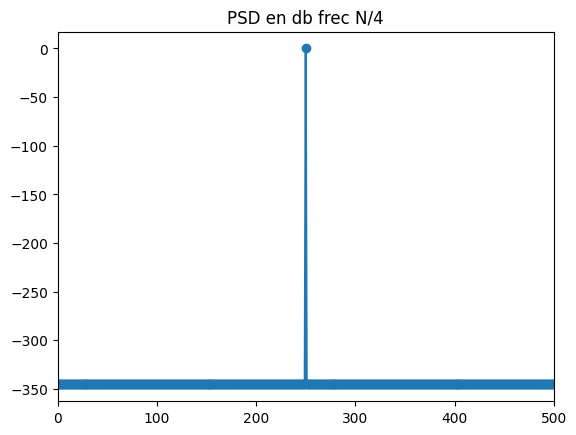

potencia de la PSD1:  1.0000000000000002


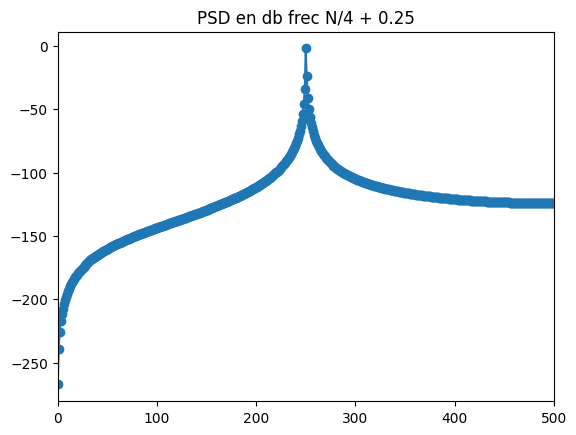

potencia de la PSD2:  0.9989999999999997


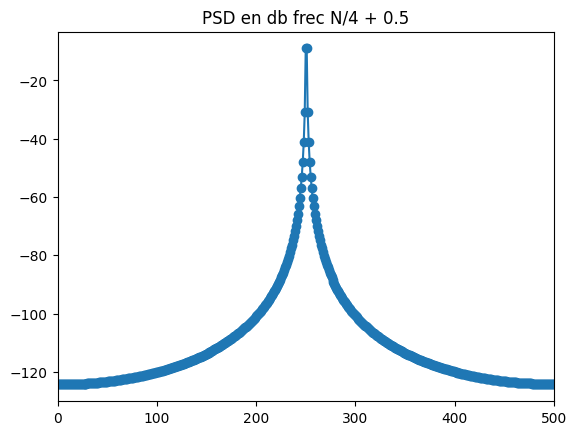

potencia de la PSD3:  1.0000000000000007


In [2]:

import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft

# Función senoidal
def sen(ff, nn, vmax=1, dc=0, ph=0, fs=2):
    n = np.arange(0, nn)
    tt = n/fs
    w0 = 2 * np.pi * ff
    xx = dc + vmax * np.sin(w0 * tt + ph)
    return tt, xx

# Parámetros
N = 1000
Fs = N
df = Fs/N
vmx= np.sqrt(2)

# Definimos las tres frecuencias pedidas
f1 = (N/4) * df
f2 = (N/4 + 0.25) * df
f3 = (N/4 + 0.5) * df

#eje frecuencia

frec = np.arange(N) * df
frec_positiva = frec[:N//2 + 1]

tt, x1 = sen(ff=f1, nn=N, vmax= vmx,fs=Fs)
tt, x2 = sen(ff=f2, nn=N, vmax= vmx, fs=Fs)
tt, x3 = sen(ff=f3, nn=N, vmax= vmx, fs=Fs)

#PSD

X1 = fft(x1)/N
X2 = fft(x2)/N
X3 = fft(x3)/N

PSD1 = (np.abs(X1))**2
PSD2 = (np.abs(X2))**2
PSD3 = (np.abs(X3))**2

#graficos
plt.figure()
plt.plot(frec, 10*np.log(PSD1*2 + 1e-15), marker="o")
plt.xlim([0,Fs/2])
plt.title("PSD en db frec N/4")
plt.show()
print("potencia de la PSD1: ", np.sum(PSD1))

plt.figure()
plt.plot(frec, 10*np.log(PSD2*2 + 1e-15), marker="o")
plt.xlim([0,Fs/2])
plt.title("PSD en db frec N/4 + 0.25")
plt.show()
print("potencia de la PSD2: ", np.sum(PSD2))

plt.figure()
plt.plot(frec, 10*np.log(PSD3*2 + 1e-15), marker="o")
plt.xlim([0,Fs/2])
plt.title("PSD en db frec N/4 + 0.5")
plt.show()
print("potencia de la PSD3: ", np.sum(PSD3))


Se puede apreciar como la desintonia respecto a un valor de $k \, \Delta f$ resulta en que el punto máximo de la PSD no coincida con un bin. Por lo tanto el resto de bines tampoco coinciden con los ceros de la FFT y muestran otros valores intermedios entre ellos. Al realizar las sumatorias de las PSD todas dieron valores casi identicos al 1 demostrando que aunque se vean distintos los gráficos no cambian las potencias
Luego se graficaron las mismas funciones pero aplicando la tecnica de zero padding

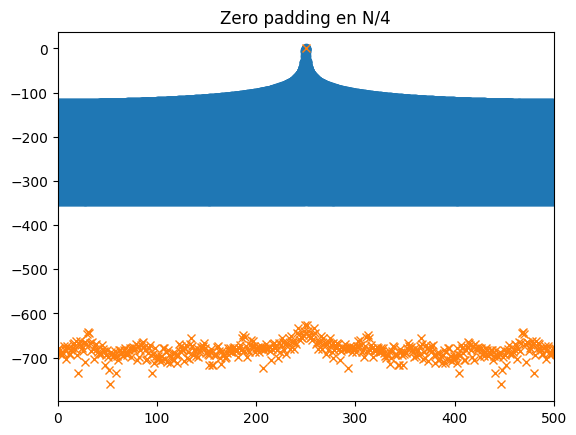

potencia de la PSD1 con padding:  1.0000000000000004


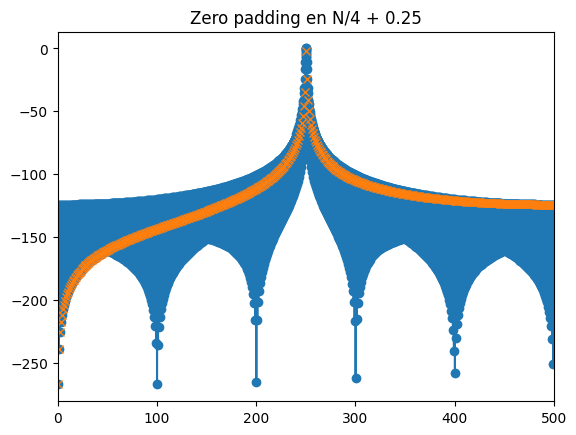

potencia de la PSD2 con padding:  0.9989999999999999


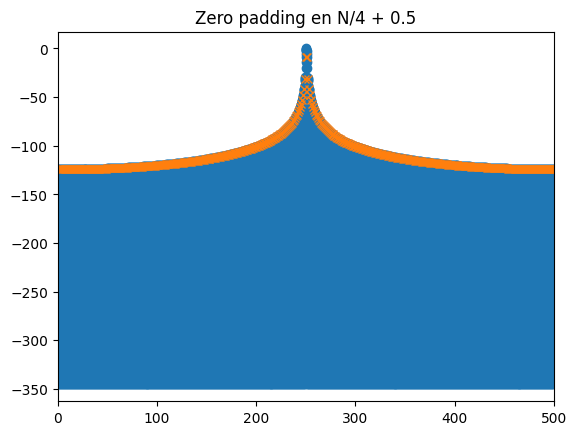

potencia de la PSD3 con padding:  1.0000000000000004


In [3]:
#Aplico zero-padding
cant_pad = 9 #cantidad de ceros respecto a las muestras de la señal
Npad = np.zeros(cant_pad*N)

x1_pad = np.concatenate((x1,Npad))
x2_pad = np.concatenate((x2,Npad))
x3_pad = np.concatenate((x3,Npad))

muestras_tot = cant_pad*N + N
factor_escala = muestras_tot/N

X1_pad = fft(x1_pad)/N
X2_pad = fft(x2_pad)/N
X3_pad = fft(x3_pad)/N

PSD1_pad = (np.abs(X1_pad))**2
PSD2_pad = (np.abs(X2_pad))**2
PSD3_pad = (np.abs(X3_pad))**2

frec_pad = np.arange(muestras_tot) * df/factor_escala

plt.figure()
plt.plot(frec_pad, 10*np.log(PSD1_pad*2 + 1e-15), marker='o')
plt.plot(frec, 10*np.log(PSD1*2), 'x')
plt.xlim([0,Fs/2])
plt.title("Zero padding en N/4")
plt.show()
print("potencia de la PSD1 con padding: ", np.sum(PSD1_pad)/factor_escala)

plt.figure()
plt.plot(frec_pad, 10*np.log(PSD2_pad*2 + 1e-15), marker='o')
plt.plot(frec, 10*np.log(PSD2*2), 'x')
plt.xlim([0,Fs/2])
plt.title("Zero padding en N/4 + 0.25")
plt.show()
print("potencia de la PSD2 con padding: ", np.sum(PSD2_pad)/factor_escala)

plt.figure()
plt.plot(frec_pad, 10*np.log(PSD3_pad*2 + 1e-15), marker='o')
plt.plot(frec, 10*np.log(PSD3*2), 'x')
plt.xlim([0,Fs/2])
plt.title("Zero padding en N/4 + 0.5")
plt.show()
print("potencia de la PSD3 con padding: ", np.sum(PSD3_pad)/factor_escala)



Limitando el eje X y el eje Y para apreciar mejor la forma del gráfico de las 3 señales queda de esta manera

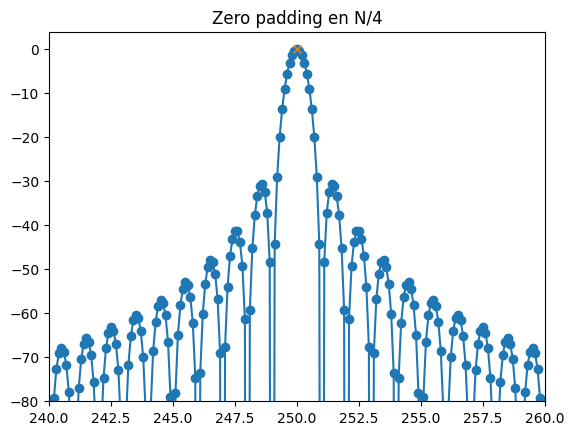

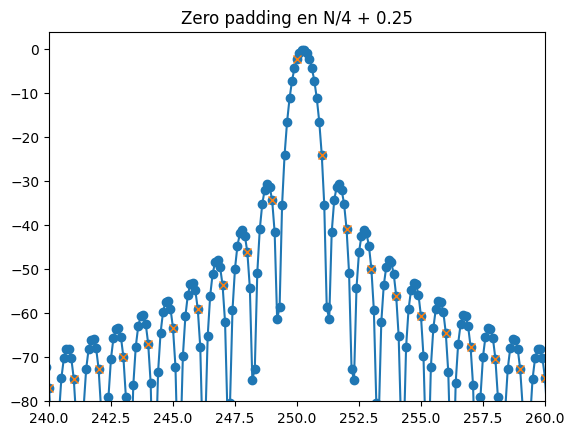

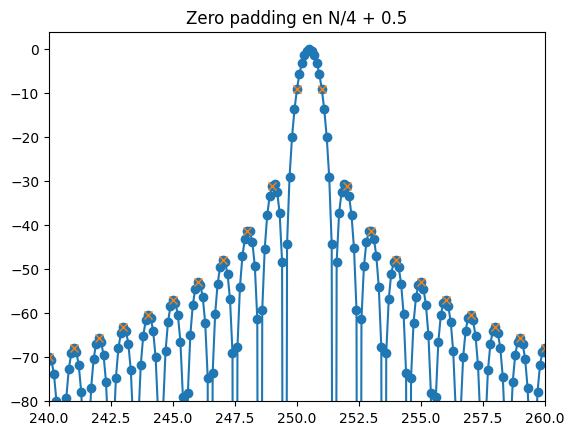

In [12]:
plt.figure()
plt.plot(frec_pad, 10*np.log(PSD1_pad*2 + 1e-15), marker='o')
plt.plot(frec, 10*np.log(PSD1*2), 'x')
plt.xlim([N/4 - 10, N/4 + 10])
plt.ylim([-80,4])
plt.title("Zero padding en N/4")
plt.show()

plt.figure()
plt.plot(frec_pad, 10*np.log(PSD2_pad*2 + 1e-15), marker='o')
plt.plot(frec, 10*np.log(PSD2*2), 'x')
plt.xlim([N/4 - 10, N/4 + 10])
plt.ylim([-80,4])
plt.title("Zero padding en N/4 + 0.25")
plt.show()

plt.figure()
plt.plot(frec_pad, 10*np.log(PSD3_pad*2 + 1e-15), marker='o')
plt.plot(frec, 10*np.log(PSD3*2), 'x')
plt.xlim([N/4 - 10, N/4 + 10])
plt.ylim([-80,4])
plt.title("Zero padding en N/4 + 0.5")
plt.show()


Aplicar la técnica del zero padding tiene un efecto interpolador en la PSD de la señal, permite apreciar una mayor cantidad de puntos del espectro de potencia. Así podemos visualizar que el corrimiento que se le dió al valor de la frecuencia respecto de $k \, \Delta f$ no altera la los valores de la FFT, simplemente la visualización del gráfico. Sobre la potencia de la señal, debe ser escalada correctamente para que no de un resultado erroneo, lo mismo con el $\Delta f$. Ambos deben ser divididos por el factor de escala del zero padding, o sea, el factor por el que se multiplicaron las muestras iniciales de la señal.

#### Conclusiones
Pude resolver la acividad con mayor claridad que el año pasado. No tuve que recurrir a la inteligencia artificial mas que para realizar las formulas con LaTex en el informe.